In [1]:
import os
import json
import gzip
import pandas as pd
import numpy as np

import scipy.sparse as spsparse
import scipy.stats as spstats

from statsmodels.stats.multitest import multipletests as holm
import statsmodels.api as sm

import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms

import seaborn as sns

In [2]:
colours=['#8D95A0','#2171b5','#DA6437']

# Number of publications and nations in the OpenAlex dataset

In [8]:
cites=pd.read_csv('CountryData2/oa_countrycites_noselfauthor.csv.gz', nrows=20)

In [9]:
cites

,CitedPublicationId,CitingCountry,CountryCitations
0,285,AM,1
1,285,BR,1
2,285,CH,3
3,285,CN,3
4,285,CZ,1
5,285,DE,2
6,285,GB,2
7,285,IN,5
8,285,IT,1
9,285,KR,1


In [4]:
num_pubs=cites['CitedPublicationId'].nunique()

print(f'-----number of publications: {num_pubs}')

num_citing_nations=cites['CitingCountry'].nunique()

print(f'-----number of citing nations: {num_citing_nations}')

-----number of publications: 57528783
-----number of citing nations: 226


In [6]:
del cites

In [5]:
dfself_vars=pd.read_csv('RegressionSelfCitation/SelfCitation_Plus_Covariates_noselfauthor_07172025.csv')
num_source_nations=dfself_vars['Country'].nunique()

print(f'-----number of citing nations: {num_source_nations}')

-----number of citing nations: 221


In [30]:
dfself_vars

,CitingCountry,Year,Country,AUC,Cov,N,zscore,pvalue,significant,NumPub,...,NResearchers,Pop,PAT_total,logPop,pub_capita,income_level,sig_direction,developed,income_group,logzscore
42,AE,2005,AE,0.591907,0.001033,57,2.858949,2.125238e-03,True,805,...,NaN,4664790.0,NaN,6.668832,0.000173,H,1.0,1,H,0.642495
43,AE,2006,AE,0.587686,0.000783,73,3.133551,8.635254e-04,True,920,...,NaN,5009100.0,NaN,6.699760,0.000184,H,1.0,1,H,0.668843
44,AE,2007,AE,0.573666,0.000880,66,2.482616,6.521079e-03,True,991,...,NaN,5624635.0,NaN,6.750094,0.000176,H,1.0,1,H,0.603574
45,AE,2008,AE,0.544130,0.000549,88,1.883059,2.984619e-02,False,1155,...,NaN,6302664.0,NaN,6.799524,0.000183,H,0.0,1,H,0.533316
46,AE,2009,AE,0.595620,0.000641,95,3.777960,7.905909e-05,True,1258,...,NaN,6707058.0,NaN,6.826532,0.000188,H,1.0,1,H,0.725039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,ZW,2015,ZW,0.584106,0.000384,146,4.289736,8.944295e-06,True,1125,...,NaN,14399013.0,1.447158,7.158333,0.000078,L,1.0,0,LM-L,0.765004
10983,ZW,2016,ZW,0.622878,0.000369,176,6.396423,7.952948e-11,True,994,...,NaN,14600294.0,1.113943,7.164362,0.000068,L,1.0,0,LM-L,0.899152
10984,ZW,2017,ZW,0.630882,0.000280,230,7.827564,2.487059e-15,True,1207,...,NaN,14812482.0,NaN,7.170628,0.000081,L,1.0,0,LM-L,0.971226
10985,ZW,2018,ZW,0.638063,0.000324,195,7.669365,8.642504e-15,True,1199,...,NaN,15034452.0,NaN,7.177088,0.000080,LM,1.0,0,LM-L,0.963822


# Dataset

In [64]:
dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')
dfself_vars['Country'].nunique()

134

# Table 1: Descriptive statistics of main variables

In [19]:
import copy
dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')


filename_suffix='noselfauthor'

main_vars=['Year','normalized_frac_top','hit_rate','novel_pct10_rate','disrupt_top5_rate',
           'zscore','FracInternationalAuthors',
           'GDP_PCAP','RND_per','NResearchers','income_level','polity2']

desc_data=copy.deepcopy(dfself_vars)

num_countries=desc_data['Country'].nunique()

print(f'number of countries: {num_countries}')
print('-----------------')

print(f'number of obs: {desc_data.shape[0]}')
print('-----------------')


desc_data['GDP_PCAP']=desc_data['GDP_PCAP']**10
desc_stats = desc_data[main_vars].describe().T

desc_stats['obs'] = desc_data[main_vars].count()

summary_table = desc_stats[['obs', 'min', 'max', 'mean', 'std']].round(3)

summary_table.index=['Year','Top jouranl rate','Hit rate','Novelty rate','Disruption rate','Citation self-preference',
                     'International collaboration','GDP per capita',
                     'R&D expenditure percentage','Number of researchers per million','Democracy score']

summary_table.reset_index(names=['Variable'], inplace=True)
summary_table.rename(columns={'obs':'Observations','min':'Minimum','max':'Maximum','mean':'Mean','std':'Std'})

print(summary_table.to_latex(index=False, caption='Descriptive statistics of main variables', 
                             position='H', label='tbl:desc',float_format="%.2f"))

number of countries: 134
-----------------
number of obs: 2501
-----------------
\begin{table}[H]
\caption{Descriptive statistics of main variables}
\label{tbl:desc}
\begin{tabular}{lrrrrr}
\toprule
Variable & obs & min & max & mean & std \\
\midrule
Year & 2501 & 1990.00 & 2019.00 & 2007.26 & 8.31 \\
Top jouranl rate & 2501 & 0.01 & 2.03 & 0.96 & 0.25 \\
Hit rate & 2501 & 0.00 & 0.26 & 0.10 & 0.05 \\
Novelty rate & 2501 & 0.02 & 0.35 & 0.19 & 0.05 \\
Disruption rate & 2501 & 0.04 & 0.41 & 0.10 & 0.03 \\
Citation self-preference & 2501 & -1.80 & 291.21 & 17.16 & 21.80 \\
International collaboration & 2501 & 0.05 & 0.90 & 0.39 & 0.15 \\
GDP per capita & 2423 & 6414.39 & 10467722.40 & 1922339.82 & 2053125.47 \\
R&D expenditure percentage & 1559 & 0.01 & 5.33 & 1.16 & 0.98 \\
Number of researchers per million & 1303 & 10.11 & 8328.97 & 2340.23 & 1945.03 \\
Democracy score & 2192 & -10.00 & 10.00 & 5.02 & 6.31 \\
\bottomrule
\end{tabular}
\end{table}



# Table S1: Correlation matrix between main variables

In [17]:
print(dfself_vars['NResearchers'].describe())
print((dfself_vars['NResearchers'] <= 0).sum())  # count zeros or negatives
print(dfself_vars['NResearchers'].isnull().sum())


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: NResearchers, dtype: float64
0
2501


In [25]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')

main_vars  = ['normalized_frac_top', 'hit_rate', 'novel_pct10_rate', 'disrupt_top5_rate',
              'logzscore', 'FracInternationalAuthors', 'GDP_PCAP', 'RND_per', 'NResearchers', 'polity2']

var_names  = ['Top journal rate', 'Hit rate', 'Novelty rate', 'Disruption rate',
              'Citation self-preference', 'International collaboration', 'GDP per capita',
              'R&D expenditure as % of GDP', 'Number of researchers per million', 'Democracy score']

dfself_vars['NResearchers'] = np.log10(dfself_vars['NResearchers']+1)

df_corr = dfself_vars[main_vars].dropna()

def add_significance_stars(corr_val, p_val):
    if p_val <= 0.01:
        return f"{corr_val:.3f}***"
    elif p_val <= 0.05:
        return f"{corr_val:.3f}**"
    elif p_val <= 0.1:
        return f"{corr_val:.3f}*"
    else:
        return f"{corr_val:.3f}"

corr_matrix = pd.DataFrame(index=var_names, columns=var_names, dtype=object)

for i, var1 in enumerate(main_vars):
    for j, var2 in enumerate(main_vars):
        label1 = var_names[i]
        label2 = var_names[j]
        if i == j:
            corr_matrix.loc[label1, label2] = "1.000"
        elif i > j:
            # drop NaN pairwise, not listwise
            pair = dfself_vars[[var1, var2]].dropna()
            if len(pair) < 2:
                corr_matrix.loc[label1, label2] = "-"
            else:
                corr_coef, p_value = pearsonr(pair[var1], pair[var2])
                corr_matrix.loc[label1, label2] = add_significance_stars(corr_coef, p_value)
        else:
            corr_matrix.loc[label1, label2] = ""
            
latex_table = corr_matrix.to_latex(
    index=True,
    header=True,
    caption="Correlation matrix between main variables",
    label="tab:correlation_matrix",
    position='H',
    escape=False
)
print(latex_table)

\begin{table}[H]
\caption{Correlation matrix between main variables}
\label{tab:correlation_matrix}
\begin{tabular}{lllllllllll}
\toprule
 & Top journal rate & Hit rate & Novelty rate & Disruption rate & Citation self-preference & International collaboration & GDP per capita & R&D expenditure as % of GDP & Number of researchers per million & Democracy score \\
\midrule
Top journal rate & 1.000 &  &  &  &  &  &  &  &  &  \\
Hit rate & 0.775*** & 1.000 &  &  &  &  &  &  &  &  \\
Novelty rate & 0.483*** & 0.556*** & 1.000 &  &  &  &  &  &  &  \\
Disruption rate & -0.498*** & -0.315*** & -0.278*** & 1.000 &  &  &  &  &  &  \\
Citation self-preference & 0.322*** & 0.377*** & 0.334*** & -0.251*** & 1.000 &  &  &  &  &  \\
International collaboration & 0.355*** & 0.567*** & 0.364*** & -0.043** & -0.222*** & 1.000 &  &  &  &  \\
GDP per capita & 0.509*** & 0.378*** & 0.003 & -0.451*** & 0.314*** & -0.137*** & 1.000 &  &  &  \\
R&D expenditure as % of GDP & 0.571*** & 0.510*** & 0.339*** & -0.4

In [26]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')

main_vars = ['normalized_frac_top', 'hit_rate', 'novel_pct10_rate', 'disrupt_top5_rate',
             'logzscore', 'FracInternationalAuthors', 'GDP_PCAP', 'RND_per', 'NResearchers', 'polity2']

var_names = ['Top journal rate', 'Hit rate', 'Novelty rate', 'Disruption rate',
             'Citation self-preference', 'International collaboration', 'GDP per capita',
             'R\\&D expenditure as \\% of GDP', 'Number of researchers per million', 'Democracy score']

dfself_vars['NResearchers'] = np.log10(dfself_vars['NResearchers'] + 1)

def add_significance_stars(corr_val, p_val):
    if p_val <= 0.01:
        return f"{corr_val:.3f}***"
    elif p_val <= 0.05:
        return f"{corr_val:.3f}**"
    elif p_val <= 0.1:
        return f"{corr_val:.3f}*"
    else:
        return f"{corr_val:.3f}"

col_labels = [str(i+1) for i in range(len(var_names))]
corr_matrix = pd.DataFrame(index=var_names, columns=col_labels, dtype=object)

for i, var1 in enumerate(main_vars):
    for j, var2 in enumerate(main_vars):
        row_label = var_names[i]
        col_label = col_labels[j]  # always use number as column key
        if i == j:
            corr_matrix.loc[row_label, col_label] = "1.000"
        elif i > j:
            pair = dfself_vars[[var1, var2]].dropna()
            if len(pair) < 2:
                corr_matrix.loc[row_label, col_label] = "-"
            else:
                corr_coef, p_value = pearsonr(pair[var1], pair[var2])
                corr_matrix.loc[row_label, col_label] = add_significance_stars(corr_coef, p_value)
        else:
            corr_matrix.loc[row_label, col_label] = ""

# add row number as first column
corr_matrix.insert(0, 'Variable', [f"({i+1}) {name}" for i, name in enumerate(var_names)])

latex_table = corr_matrix.to_latex(
    index=False,
    header=True,
    caption="Correlation matrix between main variables. *** p$<$0.01, ** p$<$0.05, * p$<$0.1",
    label="tab:correlation_matrix",
    position='H',
    escape=False,
    column_format='l' + 'r' * len(col_labels)
)

# wrap in adjustbox
latex_table = latex_table.replace(
    '\\begin{tabular}',
    '\\begin{adjustbox}{max width=\\textwidth}\n\\begin{tabular}'
).replace(
    '\\end{tabular}',
    '\\end{tabular}\n\\end{adjustbox}'
)

print(latex_table)

\begin{table}[H]
\caption{Correlation matrix between main variables. *** p$<$0.01, ** p$<$0.05, * p$<$0.1}
\label{tab:correlation_matrix}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Variable & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 \\
\midrule
(1) Top journal rate & 1.000 &  &  &  &  &  &  &  &  &  \\
(2) Hit rate & 0.775*** & 1.000 &  &  &  &  &  &  &  &  \\
(3) Novelty rate & 0.483*** & 0.556*** & 1.000 &  &  &  &  &  &  &  \\
(4) Disruption rate & -0.498*** & -0.315*** & -0.278*** & 1.000 &  &  &  &  &  &  \\
(5) Citation self-preference & 0.322*** & 0.377*** & 0.334*** & -0.251*** & 1.000 &  &  &  &  &  \\
(6) International collaboration & 0.355*** & 0.567*** & 0.364*** & -0.043** & -0.222*** & 1.000 &  &  &  &  \\
(7) GDP per capita & 0.509*** & 0.378*** & 0.003 & -0.451*** & 0.314*** & -0.137*** & 1.000 &  &  &  \\
(8) R\&D expenditure as \% of GDP & 0.571*** & 0.510*** & 0.339*** & -0.484*** & 0.503*** & -0.005 & 0.636*** & 1.000 &  &  \\
(9) Nu

# Figure 2: Association between international collaboration, citation self-preference and scientific quality. 

In [48]:
def top_vs_international(subax, data,x_var,y_var,hue,legend_title,i):


    data['q33'] = data.groupby('Year')['zscore'].transform(lambda x: x.quantile(0.33))
    data['q66'] = data.groupby('Year')['zscore'].transform(lambda x: x.quantile(0.66))
    
    conditions = [
        (data['significant'] == 0),                    # Condition for non-significant
        (data['zscore'] > data['q66']),                           # Condition for high (above 66th percentile)
        (data['zscore'] > data['q33']) & (data['zscore'] <= data['q66']),  # Condition for middle (between 33rd and 66th percentiles)
        (data['zscore'] <= data['q33'])                           # Condition for low (below 33rd percentile)
    ]
    
    choices = ['Non-significant', 'Top 33%', 'Middle 33-66%', 'Bottom 33%']
    
    data['groups'] = np.select(conditions, choices, default=np.nan)
    
    data = data.drop(columns=['q33', 'q66'])
    
    data = data.reset_index(drop=True)
    data.sort_values(by=['Year','Country',])

    #plt.subplots(1, 1, figsize=(13, 8))
    
    custom_colors = {
    'Non-significant': '#8D95A0',
    'Top 33%':purple_colors[7],# '#DA6437', 
    'Middle 33-66%':purple_colors[4],# '#F6B48F',
    'Bottom 33%': purple_colors[1],#'#F3DCC8'
    }
    
    ax=sns.scatterplot(ax=subax, data=data, x=x_var,y=y_var, s=80, alpha=0.95, hue=hue, palette=custom_colors, c='#E18683')
    
    ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,0.8])
    ax.tick_params(axis='both', which='major', labelsize=22)
    

    ax.set_xlabel('International collaboration',fontsize=28)
    ax.set_ylabel('Top journal share',fontsize=28)


    ranges = [(0.2,0.3), (0.3, 0.4),(0.4,0.5), (0.5, 0.6)]
    colors = ["whitesmoke","gainsboro","whitesmoke","gainsboro",]
   
    x=data[x_var]
    for (start, end), color in zip(ranges[0:i], colors):
        ax.fill_between(x, -0.25, 2.3, where=(x >= start) & (x <= end), color=color, alpha=0.6, zorder=0)

    x_ranges = [(0.2, 0.3), (0.3, 0.4), (0.4, 0.5),(0.5, 0.6)]
    labels = ['B', 'C', 'D', 'E']

    for i, (x_start, x_end) in enumerate(x_ranges):
        x_center = (x_start + x_end) / 2  # Calculate the center of the range
        ax.text(x_center, -0.15, labels[i], ha='center', va='bottom', fontsize=23,fontweight='bold')


    from matplotlib.patches import Patch

    handles, labels = ax.get_legend_handles_labels()

    desired_order = [ 'Top 33%', 'Middle 33-66%', 'Bottom 33%','Non-significant']  # Replace with your categories
    
    ordered_handles = []
    ordered_labels = []
    for category in desired_order:
        if category in labels:
            idx = labels.index(category)
            ordered_handles.append(handles[idx])
            ordered_labels.append(labels[idx])

    ax.legend(ordered_handles, ordered_labels,frameon=False,  title='Citation self-preference',fontsize=23, 
              title_fontsize=23,loc='upper left',bbox_to_anchor=(0, 0.99), ncol=1 ) #bbox_to_anchor=(0.25, 0.95)

    from scipy.stats import linregress
    
    x=data[x_var]
    y=data[y_var]
    x_normalized = (x - x.mean()) / x.std()
    y_normalized = (y - y.mean()) / y.std()
    
    # Run regression on normalized data
    slope, intercept, r, p, se = linregress(x_normalized, y_normalized)
    r_squared = r**2
    
    stats_text = (#f"$R^2$ = {r_squared:.2f}\n"
                  f"$r$ = {slope:.2f}\n"
              #f"r = {r:.2f}\n"
              f"p = {p:.3f}"
             )
    ax.text(0.75, 0.95, stats_text, transform=ax.transAxes, fontsize=23, verticalalignment='top')

In [49]:
def conditional_plot(subax,data,i):
    
    ax=sns.regplot(ax=subax, data=data, x='logzscore',y='normalized_frac_top', color='#8D95A0', 
                   line_kws={"color": '#b57294', 'lw':3} , scatter_kws={"s": 40, 'edgecolor':'w'})
    
    ax.tick_params(labelsize=23) 
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim([-0.1,2.5])
    ax.set_ylim([-0.1,2.1])
    for spine in ax.spines.values():
        spine.set_linewidth(0) 

    
    #ax.grid(axis='y',)

    from scipy.stats import linregress

    x=data['logzscore']
    y=data['normalized_frac_top']
    x_normalized = (x - x.mean()) / x.std()
    y_normalized = (y - y.mean()) / y.std()
    slope, intercept, r, p, se = linregress(x_normalized, y_normalized)
    r_squared = r**2

    stats_text = (#f"$R^2$ = {r_squared:.2f}\n"
              f"$r$ = {slope:.2f}\n"
              #f"r = {r:.2f}\n"
              f"p = {p:.3f}"
                 )
    ax.text(0.05, 0.85, stats_text, transform=ax.transAxes, fontsize=23, )

   

In [50]:
cmap = sns.cubehelix_palette(as_cmap=True)

n = 10
purple_colors = [mcolors.to_hex(cmap(i / (n - 1))) for i in range(n)]
print(purple_colors)

['#edd1cb', '#e4b8b8', '#d8a0aa', '#c8879e', '#b57294', '#9d5d89', '#834c7d', '#653b6c', '#492d58', '#2d1e3e']


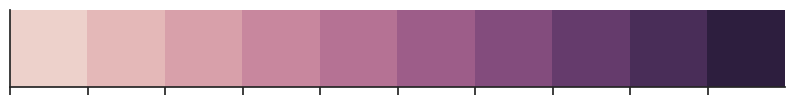

In [51]:
sns.palplot(purple_colors)

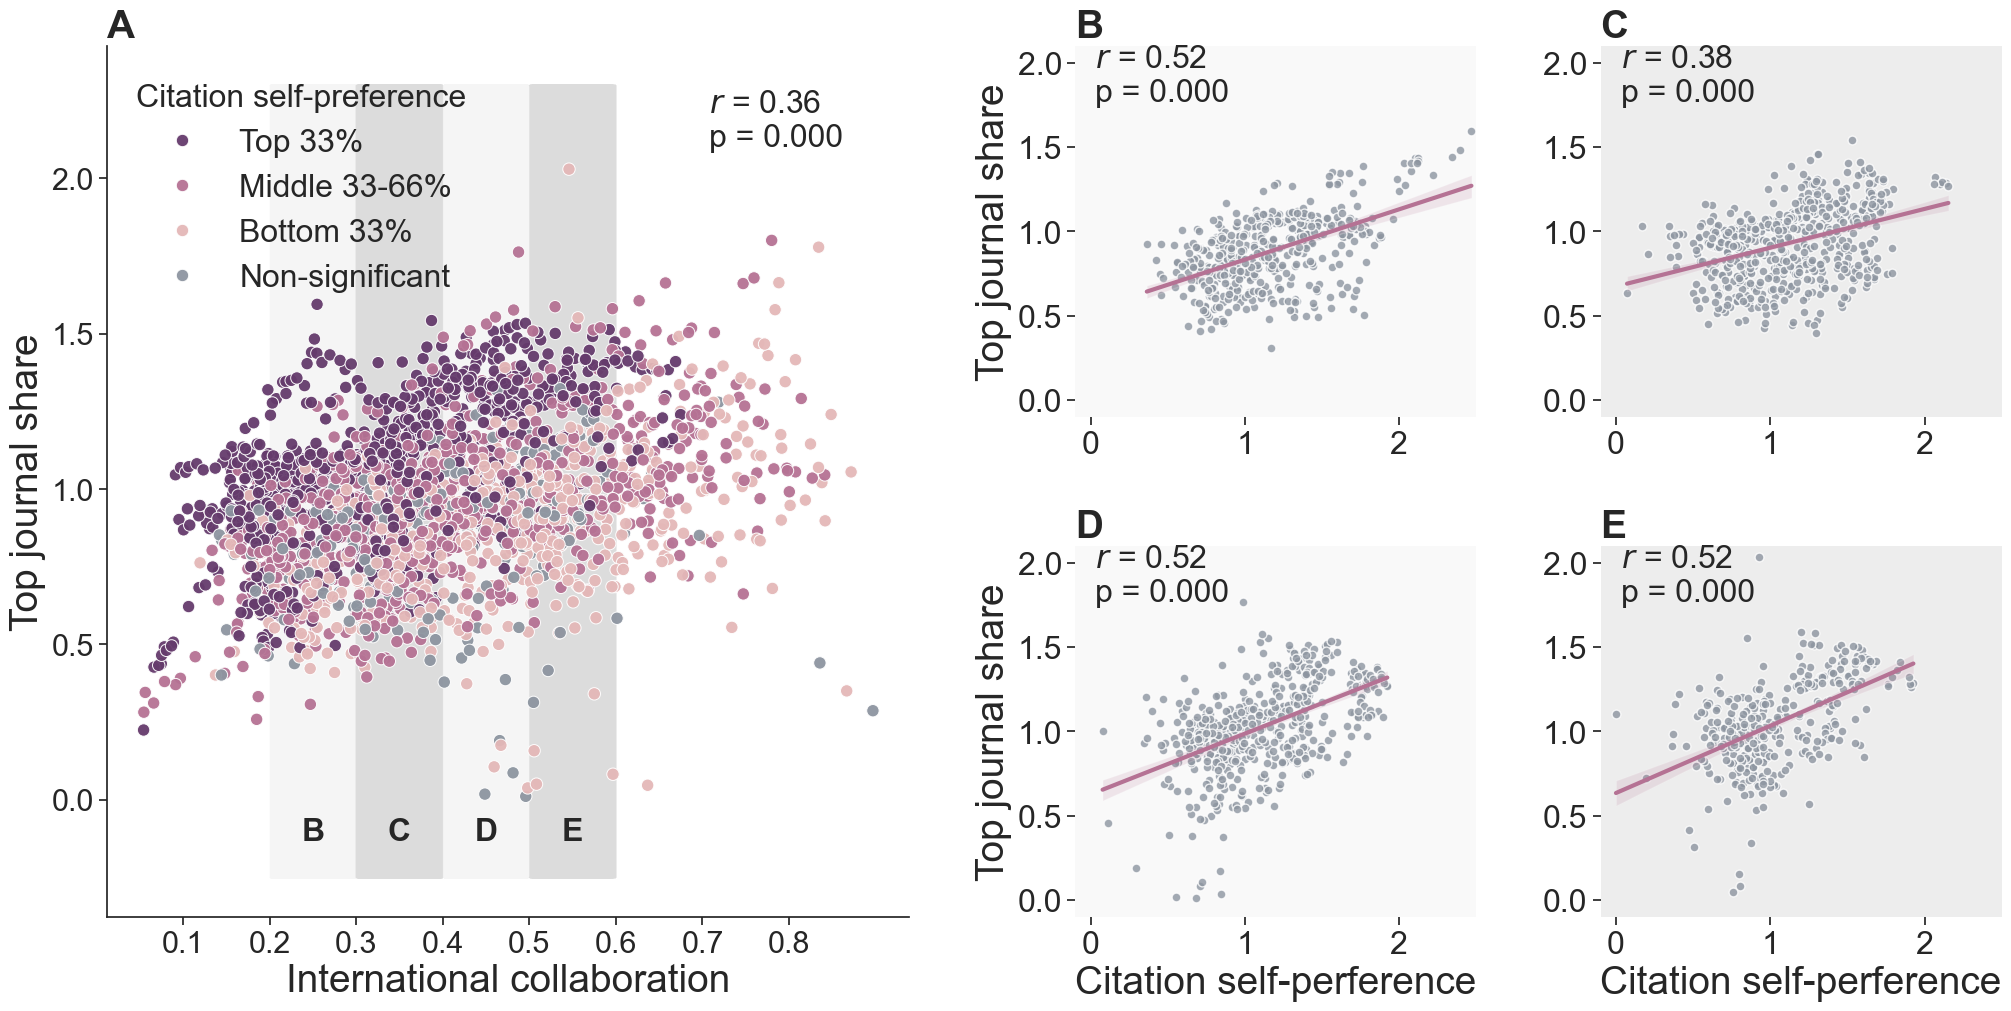

In [52]:
custom_params = {"axes.spines.bottom": True, "axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.left": True,"ytick.left":True, "xtick.bottom":True}
sns.set_theme(style='ticks', rc=custom_params)
    

layout = [
    ["A", "B",'C',],  
    ["A", "D",'E',] 
]

fig, ax_dict = plt.subplot_mosaic(layout, figsize=(20, 10), 
                                  gridspec_kw={'height_ratios': [1, 1],'width_ratios': [2, 1,1],  "hspace": 0.05,
                                               "wspace": 0.1},
                                 constrained_layout=True, )

for label, ax in ax_dict.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=28, )  # Title at the upper left corner
    ax.title.set_x(-10)

filename_suffix='noselfauthor_bootstrap'

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')

data=dfself_vars

cond1=data[(data['FracInternationalAuthors']>0.1)&(data['FracInternationalAuthors']<=0.2)]
cond2=data[(data['FracInternationalAuthors']>0.2)&(data['FracInternationalAuthors']<=0.3)]
cond3=data[(data['FracInternationalAuthors']>0.3)&(data['FracInternationalAuthors']<=0.4)]
cond4=data[(data['FracInternationalAuthors']>0.4)&(data['FracInternationalAuthors']<=0.5)]
cond5=data[(data['FracInternationalAuthors']>0.5)&(data['FracInternationalAuthors']<=0.6)]

titles=['Fraction of international authors \n 10~20%','20~30%','30~40%','40~50%','50~60%',]

top_vs_international(ax_dict["A"], data, 'FracInternationalAuthors', 
                     'normalized_frac_top','groups', 
                     'Fraction of top journal articles',4)

conditional_plot(ax_dict["B"],cond2,2)
conditional_plot(ax_dict["C"],cond3,3)
conditional_plot(ax_dict["D"],cond4,4)
conditional_plot(ax_dict["E"],cond5,5)


for index, key in enumerate(['B', 'C', 'D', 'E']):
    ax_dict[key].set_xlabel('Citation self-perference',fontsize=28)
    ax_dict[key].set_ylabel('Top journal share',fontsize=28)

    if key in ['C','E']: 
        ax_dict[key].set_ylabel("")

    if key in ['B','C']: 
        ax_dict[key].set_xlabel("")
    
         

import matplotlib.colors as mcolors


for key in ['B',  'D',  ]:
    ax_dict[key].set_facecolor(mcolors.to_rgba("whitesmoke", alpha=0.5)) 

for key in ['C',  'E',]:
    ax_dict[key].set_facecolor(mcolors.to_rgba("gainsboro", alpha=0.5))

plt.savefig(f"FigureSelfCitation/NewData/conditional_relationship_{filename_suffix}.pdf", bbox_inches='tight')


# Coefficient of variation for B,C,D,E

In [53]:
results = {}

i = 0
for subset in [cond2, cond3, cond4, cond5]:
    mean_val = subset['normalized_frac_top'].mean()
    std_val = subset['normalized_frac_top'].std()
    
    dispersion = {
        'mean': mean_val,
        'std_dev': std_val,
        'cv': std_val / mean_val if mean_val != 0 else None,
        'iqr': subset['normalized_frac_top'].quantile(0.75) - subset['normalized_frac_top'].quantile(0.25),
        'range': subset['normalized_frac_top'].max() - subset['normalized_frac_top'].min(),
        'n': len(subset)
    }
    
    results[i] = dispersion
    i += 1


In [54]:
results

{0: {'mean': 0.880743986834313,
  'std_dev': 0.20916277120311672,
  'cv': 0.23748418874242597,
  'iqr': 0.28820908278697577,
  'range': 1.287535417690881,
  'n': 497},
 1: {'mean': 0.9316160938276282,
  'std_dev': 0.21330695286681384,
  'cv': 0.22896443532917418,
  'iqr': 0.3022007095097128,
  'range': 1.1472519697395196,
  'n': 620},
 2: {'mean': 1.0272476345784078,
  'std_dev': 0.25855064253335003,
  'cv': 0.25169261415672345,
  'iqr': 0.31721411143647105,
  'range': 1.7520695821373522,
  'n': 523},
 3: {'mean': 1.0452042066330016,
  'std_dev': 0.2563135831653254,
  'cv': 0.24522823534264987,
  'iqr': 0.3546373892035647,
  'range': 1.97964100556608,
  'n': 351}}

# Compare results from the paper on Open countries have strong science

## replicate the paper

In [55]:
df_open=pd.read_excel('CountryData/Caroline_data.xlsx')

country_codes=pd.read_csv('CountryData/Gravity_csv_V202211/Countries_V202211.csv')
country_codes['iso2']=country_codes['iso2'].str.strip()
country_codes['iso3']=country_codes['iso3'].str.strip()
country_dict = dict(zip(country_codes['iso3'], country_codes['iso2']))
df_open['code'] = df_open['code'].map(country_dict)


In [56]:
df_open['fracfwci (corrected)'].corr(df_open['Openness Index'])

0.6819726336929394

In [57]:
import statsmodels.formula.api as smf

df_clean = df_open[['Openness Index', 'fracfwci (corrected)']].dropna()

model = smf.ols('Q("fracfwci (corrected)") ~ Q("Openness Index")', data=df_clean).fit()

print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     Q("fracfwci (corrected)")   R-squared:                       0.465
Model:                                   OLS   Adj. R-squared:                  0.449
Method:                        Least Squares   F-statistic:                     28.69
Date:                       Thu, 26 Mar 2026   Prob (F-statistic):           6.44e-06
Time:                               21:58:04   Log-Likelihood:                 4.3525
No. Observations:                         35   AIC:                            -4.705
Df Residuals:                             33   BIC:                            -1.594
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

## Use own data

In [58]:
dfself_vars.head()

,CitingCountry,Year,Country,AUC,N,STD,zscore,pvalue,significant,NumPub,...,novel_pct10_rate,disruption_mean,disrupt_top10_rate,disrupt_top5_rate,novel_pct10_rate_norm,hit_rate,hit_rate_scinet,q33,q66,groups
0,AE,2005,AE,0.522007,57,0.019949,1.103144,0.134982,False,805,...,0.169499,0.004254,0.245540,0.102379,0.963190,0.082885,0.107570,5.604564,12.940689,Non-significant
1,AE,2006,AE,0.535211,73,0.018011,1.954971,0.025293,False,920,...,0.186072,0.003256,0.276025,0.108814,1.075293,0.091996,0.110084,5.298754,13.728225,Non-significant
2,AE,2007,AE,0.520049,66,0.019021,1.054066,0.145926,False,991,...,0.163540,0.002334,0.297686,0.119762,0.917841,0.107114,0.115356,6.187693,15.337060,Non-significant
3,AE,2008,AE,0.526826,88,0.014461,1.854976,0.031800,False,1155,...,0.167653,0.002940,0.307692,0.116653,0.906043,0.105720,0.111984,5.612512,14.586504,Non-significant
4,AE,2009,AE,0.565627,95,0.017381,3.775801,0.000080,True,1258,...,0.143354,0.002917,0.286957,0.113540,0.765525,0.117801,0.125808,6.097284,16.203209,Bottom 33%


In [59]:
countries=df_open['code'].to_list()

print(len(countries))

df_selected=dfself_vars[dfself_vars['Country'].isin(countries)]

df_selected['Country'].nunique()

36


36

In [60]:
df_selected.columns

Index(['CitingCountry', 'Year', 'Country', 'AUC', 'N', 'STD', 'zscore',
       'pvalue', 'significant', 'NumPub', 'TopJournal', 'FracTop', 'OANumPub',
       'OATopJournal', 'OAFracTop', 'normalized_frac_top', 'logNumPub',
       'FractionNationalAuthors', 'FracInternationalAuthors',
       'TopicDiversity1', 'TopicDiversity2', 'RND_per', 'PAT_res', 'PAT_nres',
       'GDP', 'GDP_PCAP', 'GNI', 'GNI_PCAP', 'NResearchers', 'Pop',
       'PAT_total', 'logPop', 'pub_capita', 'income_level', 'polity2',
       'is_democratic', 'date', 'cap_sum_index', 'gov_sum_index',
       'sig_direction', 'developed', 'income_group', 'logzscore', 'Unnamed: 0',
       'novel_pct10_rate', 'disruption_mean', 'disrupt_top10_rate',
       'disrupt_top5_rate', 'novel_pct10_rate_norm', 'hit_rate',
       'hit_rate_scinet', 'q33', 'q66', 'groups'],
      dtype='object')

In [61]:
dfself_vars['FracInternationalAuthors'].corr(dfself_vars['normalized_frac_top'])

0.3550517067403079

In [65]:
df_year=dfself_vars[dfself_vars['Year']==2013]
df_year['FracInternationalAuthors'].corr(df_year['normalized_frac_top'])

0.4555955467642843

In [63]:
df_selected['FracInternationalAuthors'].corr(df_selected['normalized_frac_top'])

0.674206951407185

In [43]:
# model = smf.ols('''Q("normalized_frac_top") ~ 
#                    Q("FracInternationalAuthors") + 
#                    C(Year)''', 
#                 data=df_selected).fit()

# print(model.summary())

In [58]:
cors=dict()

for year in range(1990, 2019):
    df_year=df_selected[df_selected['Year']==year]
    cor=df_year['FracInternationalAuthors'].corr(df_year['normalized_frac_top'])
    cors[year]=cor

<Axes: xlabel='year', ylabel='cor'>

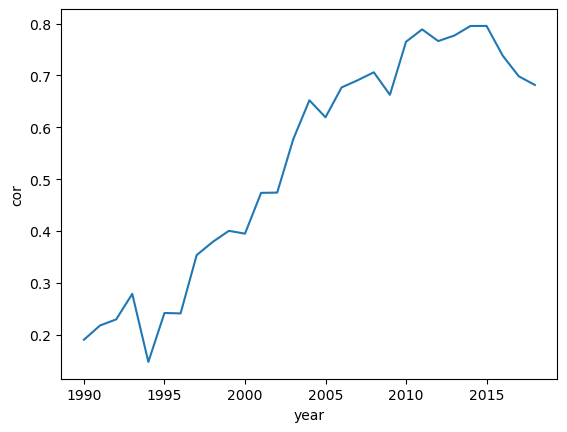

In [63]:
df=pd.DataFrame({'cor':cors}).reset_index(names=['year'])
sns.lineplot(data=df, x='year', y='cor')

In [64]:
df

,year,cor
0,1990,0.190573
1,1991,0.218086
2,1992,0.229769
3,1993,0.278945
4,1994,0.147802
5,1995,0.242179
6,1996,0.241274
7,1997,0.353800
8,1998,0.379218
9,1999,0.400505
